# German Podcast Linguistic Complexity Analysis

This notebook computes linguistic complexity metrics across German-language podcast transcripts.

**Metric categories:**
1. **Lexical Diversity** — TTR, Maas, MTLD, HD-D
2. **Information-Theoretic** — Shannon entropy at word and POS level
3. **Syntactic Complexity** — Average dependency distance, subordination index
4. **Discourse / Readability** — Lexical density, adapted Flesch reading ease
5. **Composite score** — PCA-based single complexity dimension


---

In [ ]:
import os
import re
import json
import glob
import warnings
import math
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import spacy
from lexical_diversity import lex_div as ld

warnings.filterwarnings('ignore')

DATA_DIR = Path('C:\\Users\\edwar\\OneDrive\\Uni\\SoSe2025\\Data Science for Linguists\\Project\\linguistic-data-science\\data\\data')       
RESULTS_DIR = Path('C:\\Users\\edwar\\OneDrive\\Uni\\SoSe2025\\Data Science for Linguists\\Project\\linguistic-data-science\\results')
RESULTS_DIR.mkdir(exist_ok=True)

SPACY_MODEL = 'de_core_news_lg'
nlp = spacy.load(SPACY_MODEL, disable=['ner'])   
nlp.max_length = 2_000_000                     

EPISODES_PER_PODCAST = 20

np.random.seed(42)

spaCy model loaded     : de_core_news_lg
Data directory         : C:\Users\edwar\OneDrive\Uni\SoSe2025\Data Science for Linguists\Project\linguistic-data-science\data\data
Episodes per podcast   : 20


## 1. Data Loading

We walk `data/` and collect episode transcripts. Each podcast subfolder contains `.txt` files;
the filename (without extension) is used as the episode name.
At most `EPISODES_PER_PODCAST` episodes are loaded per podcast (set in Section 0);
episodes are sorted alphabetically so the subset is deterministic.

In [ ]:
records = []

for podcast_dir in sorted(DATA_DIR.iterdir()):
    if not podcast_dir.is_dir():
        continue
    podcast_name = podcast_dir.name
    txt_files = sorted(podcast_dir.glob('*.txt'))
    if EPISODES_PER_PODCAST is not None:
        txt_files = txt_files[:EPISODES_PER_PODCAST]

    for txt_file in txt_files:
        with open(txt_file, encoding='utf-8') as f:
            text = f.read().strip()

        records.append({
            'podcast': podcast_name,
            'episode': txt_file.stem,  
            'text':    text,
        })

df_raw = pd.DataFrame(records)
print(f"Loaded {len(df_raw)} episodes from {df_raw['podcast'].nunique()} podcasts.")
print(f"Episodes per podcast: min={df_raw.groupby('podcast').size().min()}, "
      f"max={df_raw.groupby('podcast').size().max()}, "
      f"median={df_raw.groupby('podcast').size().median():.0f}")
df_raw.head(3)

Loaded 1453 episodes from 83 podcasts.
Episodes per podcast: min=1, max=20, median=20


,podcast,episode,text
0,$hz_wir_müssen_reden,2-3_jahre_dagestan_mit_baran_kok,Und welcome back zu der neuen episode von shop...
1,$hz_wir_müssen_reden,alte_weiße_männ(ag)er_mit_nonakanal,"Schatz, wir müssen reden, Folge zwei. Heute mü..."
2,$hz_wir_müssen_reden,ausreden_lassen_challenge_mit_marek_fritz,Hallihallo Leute und willkommen zu der neuen F...


In [ ]:

_NOISE_RE = re.compile(
    r'\[.*?\]'           
    r'|\(.*?\)'       
    r'|<[^>]+>',       
    re.IGNORECASE
)
_WHITESPACE_RE = re.compile(r'\s+')

def clean_transcript(text: str) -> str:
    text = _NOISE_RE.sub(' ', text)
    text = _WHITESPACE_RE.sub(' ', text)
    return text.strip()


def surface_tokens(text: str) -> list[str]:
    """Simple whitespace + punctuation split for lexical-diversity metrics."""
    return [t for t in re.split(r'\W+', text.lower()) if t]


df_raw['text_clean'] = df_raw['text'].map(clean_transcript)
df_raw['tokens']     = df_raw['text_clean'].map(surface_tokens)
df_raw['n_tokens']   = df_raw['tokens'].map(len)

print("Token count summary:")
print(df_raw['n_tokens'].describe().to_frame().T.to_string(index=False))
print(f"\nEpisodes with <100 tokens (will be excluded): {(df_raw['n_tokens'] < 100).sum()}")

Token count summary:
 count        mean         std  min    25%    50%     75%     max
1453.0 9887.862354 7458.937992 28.0 5340.0 8717.0 12871.0 94202.0

Episodes with <100 tokens (will be excluded): 6


## 3. Metric Computation

### 3.1 Lexical Diversity

All four indices operate on surface-form token lists
In German, inflectional morphology will slightly inflate TTR/HD-D relative to English,
but this is consistent across podcasts so cross-podcast comparisons remain valid.


In [ ]:
def compute_lexical_diversity(tokens: list[str]) -> dict:
    if len(tokens) < 50:
        return {'ttr': np.nan, 'maas': np.nan, 'mtld': np.nan, 'hdd': np.nan}
    try:
        return {
            'ttr':  ld.ttr(tokens),
            'maas': ld.maas_ttr(tokens),
            'mtld': ld.mtld(tokens),
            'hdd':  ld.hdd(tokens),
        }
    except Exception as e:
        return {'ttr': np.nan, 'maas': np.nan, 'mtld': np.nan, 'hdd': np.nan}


lex_div_results = df_raw['tokens'].map(compute_lexical_diversity).apply(pd.Series)
lex_div_results.describe()

Lexical diversity metrics computed.


,ttr,maas,mtld,hdd
count,1449.000000,1449.000000,1449.000000,1449.000000
mean,0.237722,0.042599,100.459503,0.883869
std,0.099345,0.004869,38.884448,0.018927
min,0.085688,0.021557,42.301814,0.804174
25%,0.174638,0.040265,72.316825,0.872522
50%,0.212620,0.043059,93.618875,0.885677
75%,0.265323,0.045962,117.818930,0.896808
max,0.768595,0.059944,362.074219,0.935982


### 3.2 Information-Theoretic Metrics

**Shannon entropy** 

- **Word entropy**
- **POS entropy**


In [ ]:
def shannon_entropy(sequence: list) -> float:

    counts = Counter(sequence)
    n = sum(counts.values())
    if n < 2:
        return np.nan
    probs = np.array(list(counts.values())) / n
    h = -np.sum(probs * np.log2(probs + 1e-12))
    return h / math.log2(n)   # normalise


def compute_entropy_metrics(tokens: list[str], doc) -> dict:
    word_h = shannon_entropy(tokens)
    pos_tags = [token.pos_ for token in doc if not token.is_space]
    pos_h = shannon_entropy(pos_tags)
    return {'word_entropy': word_h, 'pos_entropy': pos_h}


Entropy metrics will be computed during the spaCy pass in Section 3.3.


### 3.3 Syntactic Complexity via spaCy

We run the spaCy dependency parser once per episode and extract:

| Metric | Definition | Interpretation |
|--------|-----------|----------------|
| **Avg. dependency distance (ADD)** | Mean \|head_index − token_index\| per sentence | Higher → more complex, non-local dependencies |
| **Subordination index** | Proportion of tokens with a subordinating relation (`sb`, `oc`, `rc` etc.) | Higher → more embedded clauses |
| **Avg. sentence length** | Mean tokens per sentence | Proxy for syntactic load |


In [ ]:

SUBORDINATE_DEPS = {
    'oc',    # clausal object
    'rc',    # relative clause
    'sbp',   # passivised subject
    'mo',    # modifier (often adverbial clauses)
    'mnr',   # post-nominal modifier
    'cp',    # complementiser phrase
    'ac',    # adpositional case modifier (sometimes clausal)
}

CONTENT_POS = {'NOUN', 'VERB', 'ADJ', 'ADV'}


def compute_syntactic_metrics(doc) -> dict:

    distances, sub_flags, sent_lens = [], [], []

    for sent in doc.sents:
        sent_tokens = [t for t in sent if not t.is_space and not t.is_punct]
        if len(sent_tokens) < 2:
            continue
        sent_lens.append(len(sent_tokens))

        for token in sent_tokens:
            if token.head != token:   # skip root
                distances.append(abs(token.i - token.head.i))
            sub_flags.append(1 if token.dep_ in SUBORDINATE_DEPS else 0)

    return {
        'avg_dep_distance':   np.mean(distances)   if distances  else np.nan,
        'subordination_idx':  np.mean(sub_flags)   if sub_flags  else np.nan,
        'avg_sent_len':       np.mean(sent_lens)   if sent_lens  else np.nan,
    }


def compute_discourse_metrics(tokens: list[str], doc) -> dict:

  
    content_count = sum(1 for t in doc if t.pos_ in CONTENT_POS and not t.is_space)
    total_count   = sum(1 for t in doc if not t.is_space and not t.is_punct)
    lex_density = content_count / total_count if total_count > 0 else np.nan

 
    word_tokens = [t.text for t in doc if t.is_alpha]
    if not word_tokens:
        return {'lexical_density': lex_density, 'flesch_de': np.nan}

    sent_lens_w = []
    for sent in doc.sents:
        wc = sum(1 for t in sent if t.is_alpha)
        if wc > 0:
            sent_lens_w.append(wc)

    asl = np.mean(sent_lens_w) if sent_lens_w else np.nan
    asw = np.mean([len(w) / 3.0 for w in word_tokens])   
    flesch_de = 180 - asl - (58.5 * asw) if not np.isnan(asl) else np.nan

    return {'lexical_density': lex_density, 'flesch_de': flesch_de}



Syntactic & discourse metric functions defined.


In [ ]:


CACHE_PATH = RESULTS_DIR / 'spacy_metrics_cache.csv'

if CACHE_PATH.exists():
    print(f"Loading cached spaCy metrics from {CACHE_PATH}")
    spacy_df = pd.read_csv(CACHE_PATH)
else:
    print("Running spaCy pipeline — this may take a while...")
    spacy_records = []

    # Filter out very short episodes
    valid = df_raw[df_raw['n_tokens'] >= 100].copy()
    print(f"Processing {len(valid)} episodes (skipping {len(df_raw) - len(valid)} too short).")

    for i, row in valid.iterrows():
        try:
            doc = nlp(row['text_clean'])
            syn  = compute_syntactic_metrics(doc)
            disc = compute_discourse_metrics(row['tokens'], doc)
            entr = compute_entropy_metrics(row['tokens'], doc)
            spacy_records.append({
                'podcast': row['podcast'],
                'episode': row['episode'],
                **syn, **disc, **entr
            })
        except Exception as e:
            print(f"  ERROR on {row['podcast']}/{row['episode']}: {e}")
            spacy_records.append({
                'podcast': row['podcast'], 'episode': row['episode'],
                'avg_dep_distance': np.nan, 'subordination_idx': np.nan,
                'avg_sent_len': np.nan, 'lexical_density': np.nan,
                'flesch_de': np.nan, 'word_entropy': np.nan, 'pos_entropy': np.nan
            })

        if (i + 1) % 50 == 0:
            print(f"  ... {i + 1} / {len(valid)} done")

    spacy_df = pd.DataFrame(spacy_records)
    spacy_df.to_csv(CACHE_PATH, index=False)
    print(f"Saved cache to {CACHE_PATH}")

spacy_df.describe()

Running spaCy pipeline — this may take a while...
Processing 1447 episodes (skipping 6 too short).
  ... 50 / 1447 done
  ... 100 / 1447 done
  ... 150 / 1447 done
  ... 200 / 1447 done
  ... 250 / 1447 done
  ... 300 / 1447 done
  ... 350 / 1447 done
  ... 400 / 1447 done
  ... 450 / 1447 done
  ... 500 / 1447 done
  ... 550 / 1447 done
  ... 600 / 1447 done
  ... 650 / 1447 done
  ... 700 / 1447 done
  ... 750 / 1447 done
  ... 800 / 1447 done
  ... 850 / 1447 done
  ... 900 / 1447 done
  ... 950 / 1447 done
  ... 1000 / 1447 done
  ... 1050 / 1447 done
  ... 1100 / 1447 done
  ... 1150 / 1447 done
  ... 1200 / 1447 done
  ... 1250 / 1447 done
  ... 1300 / 1447 done
  ... 1350 / 1447 done
  ... 1400 / 1447 done
  ... 1450 / 1447 done
Saved cache to C:\Users\edwar\OneDrive\Uni\SoSe2025\Data Science for Linguists\Project\linguistic-data-science\results\spacy_metrics_cache.csv


,avg_dep_distance,subordination_idx,avg_sent_len,lexical_density,flesch_de,word_entropy,pos_entropy
count,1447.000000,1447.000000,1447.000000,1447.000000,1447.000000,1447.000000,1447.000000
mean,3.085094,0.338065,16.010158,0.467814,68.454087,0.684212,0.262593
std,0.515231,0.046219,3.107908,0.054255,9.073405,0.057508,0.033950
min,2.078947,0.041896,7.333333,0.029805,42.557432,0.550280,0.113587
25%,2.884770,0.325044,13.857529,0.461973,61.771097,0.642102,0.244124
50%,3.029998,0.347243,16.011905,0.475248,67.532096,0.675173,0.258323
75%,3.176534,0.363331,18.154689,0.487117,76.163548,0.711633,0.274823
max,9.818750,0.431373,26.565359,0.546341,94.104094,0.918609,0.493370


## 4. Merge All Metrics into One DataFrame

In [ ]:

df_metrics = df_raw[df_raw['n_tokens'] >= 100].copy().reset_index(drop=True)
df_metrics = pd.concat([df_metrics.reset_index(drop=True),
                         lex_div_results.loc[df_metrics.index].reset_index(drop=True)],
                        axis=1)


df_metrics = df_metrics.merge(
    spacy_df, on=['podcast', 'episode'], how='left'
)


df_metrics = df_metrics.drop(columns=['text', 'text_clean', 'tokens'], errors='ignore')

METRIC_COLS = [
    'ttr', 'maas', 'mtld', 'hdd',
    'word_entropy', 'pos_entropy',
    'avg_dep_distance', 'subordination_idx', 'avg_sent_len',
    'lexical_density', 'flesch_de',
]

print(f"Final dataset: {len(df_metrics)} episodes × {len(df_metrics.columns)} columns")
df_metrics[METRIC_COLS].describe().T.round(3)

Final dataset: 1447 episodes × 14 columns


,count,mean,std,min,25%,50%,75%,max
ttr,1443.0,0.238,0.099,0.086,0.175,0.213,0.265,0.769
maas,1443.0,0.043,0.005,0.022,0.040,0.043,0.046,0.060
mtld,1443.0,100.437,38.855,42.302,72.453,93.619,117.778,362.074
hdd,1443.0,0.884,0.019,0.804,0.873,0.886,0.897,0.936
word_entropy,1447.0,0.684,0.058,0.550,0.642,0.675,0.712,0.919
pos_entropy,1447.0,0.263,0.034,0.114,0.244,0.258,0.275,0.493
avg_dep_distance,1447.0,3.085,0.515,2.079,2.885,3.030,3.177,9.819
subordination_idx,1447.0,0.338,0.046,0.042,0.325,0.347,0.363,0.431
avg_sent_len,1447.0,16.010,3.108,7.333,13.858,16.012,18.155,26.565
lexical_density,1447.0,0.468,0.054,0.030,0.462,0.475,0.487,0.546


In [ ]:

df_metrics.to_csv(RESULTS_DIR / 'episode_metrics.csv', index=False)


Saved results/episode_metrics.csv


## 5. Podcast-Level Aggregation

Episode metrics are averaged per podcast for genre/format comparisons.
We also compute the standard deviation within each podcast as a measure of
episode-to-episode consistency.

In [ ]:

agg_funcs = {col: ['mean', 'std', 'count'] for col in METRIC_COLS}

df_podcast = df_metrics.groupby('podcast').agg(agg_funcs)
df_podcast.columns = ['_'.join(c).strip('_') for c in df_podcast.columns]
df_podcast = df_podcast.reset_index()


mean_cols = [c for c in df_podcast.columns if c.endswith('_mean')]
df_pod_means = df_podcast[['podcast'] + mean_cols].copy()
df_pod_means.columns = (
    ['podcast']
    + [c.replace('_mean', '') for c in mean_cols]
)

print(f"Podcast-level table: {len(df_pod_means)} podcasts")
df_pod_means.head()

Podcast-level table: 83 podcasts


,podcast,ttr,maas,mtld,hdd,word_entropy,pos_entropy,avg_dep_distance,subordination_idx,avg_sent_len,lexical_density,flesch_de
0,$hz_wir_müssen_reden,0.179909,0.047556,57.582149,0.848313,0.632327,0.253128,3.115142,0.337439,14.967535,0.456065,79.531224
1,0630_-_der_news-podcast,0.293971,0.041747,119.217640,0.891786,0.728679,0.286427,2.988901,0.366000,17.273739,0.491580,64.044492
2,15_minuten_der_tagesschau-podcast_am_morgen,0.360489,0.037891,142.477285,0.902309,0.763335,0.298292,2.938723,0.354990,16.442819,0.501522,62.332811
3,50+2_-_der_fussballpodcast_mit_nico_&_niklas,0.223519,0.042687,98.374644,0.889702,0.675722,0.265478,3.099217,0.348261,16.457943,0.447318,70.501438
4,5_minuten_harry_podcast_von_coldmirror,0.260547,0.037434,135.560838,0.905953,0.708606,0.264459,3.170470,0.312907,18.369199,0.467207,63.052023


## 6. Composite Complexity Score (PCA)

Individual metrics are correlated and have different scales. We use PCA to derive
a single **complexity score** (PC1) that captures the dominant axis of variance.

> **Note on Flesch:** Higher Flesch = *easier* text. We negate it so that all metrics
> point in the same direction (higher = more complex).

In [ ]:
# Flip Flesch so higher = more complex (like all other metrics)
# Note: took out SI index
df_metrics['flesch_de_inv'] = -df_metrics['flesch_de']
df_pod_means['flesch_de_inv'] = -df_pod_means['flesch_de']

PCA_COLS = [
    'ttr', 'maas', 'mtld', 'hdd',
    'word_entropy', 'pos_entropy',
    'avg_dep_distance', 'avg_sent_len',
    'lexical_density', 'flesch_de_inv',
]

pca_data = df_metrics[PCA_COLS].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(pca_data)

pca = PCA(n_components=min(len(PCA_COLS), 5))
pcs = pca.fit_transform(X_scaled)

df_metrics.loc[pca_data.index, 'complexity_score'] = pcs[:, 0]

exp_var = pca.explained_variance_ratio_
print("Explained variance per PC:")
for i, v in enumerate(exp_var):
    print(f"  PC{i+1}: {v:.1%}")

loadings = pd.DataFrame(
    pca.components_.T,
    index=PCA_COLS,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)]
).round(3)
print("\nPC1 loadings (complexity score):")
print(loadings['PC1'].sort_values(ascending=False).to_string())

Explained variance per PC:
  PC1: 43.5%
  PC2: 19.9%
  PC3: 15.0%
  PC4: 11.0%
  PC5: 4.3%

PC1 loadings (complexity score):
mtld                0.412
hdd                 0.371
ttr                 0.369
word_entropy        0.350
flesch_de_inv       0.333
pos_entropy         0.324
lexical_density     0.165
avg_sent_len        0.086
avg_dep_distance   -0.166
maas               -0.396


In [ ]:
podcast_complexity = (
    df_metrics.groupby('podcast')['complexity_score']
    .mean()
    .reset_index()
    .rename(columns={'complexity_score': 'complexity_score'})
)
df_pod_means = df_pod_means.merge(podcast_complexity, on='podcast', how='left')
df_pod_means.to_csv(RESULTS_DIR / 'podcast_means.csv', index=False)

Saved results/podcast_means.csv


### 7.2 PCA scree plot & loadings

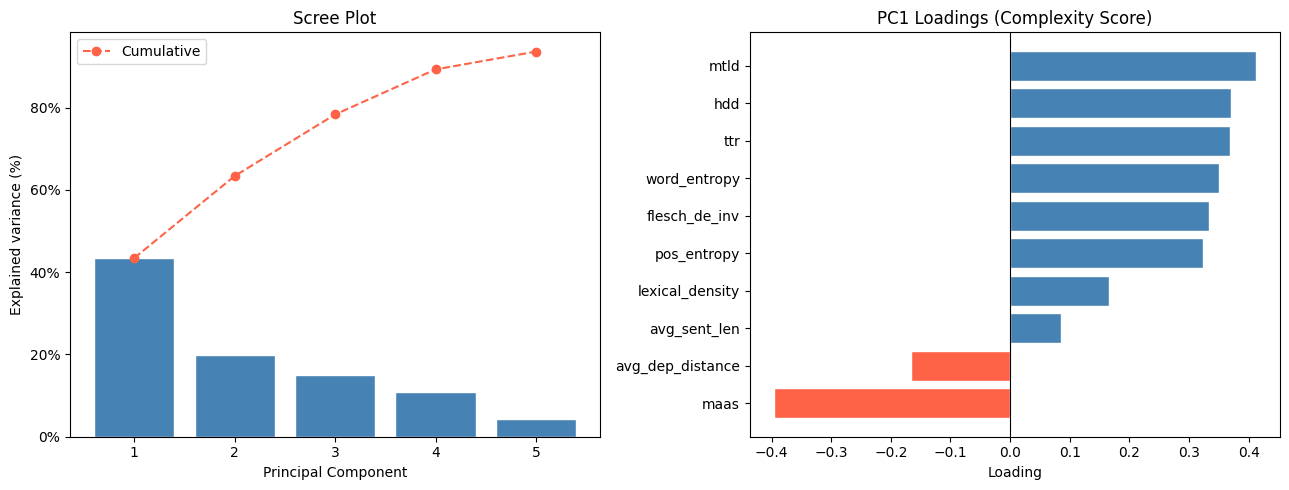

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.bar(range(1, len(exp_var)+1), exp_var * 100, color='steelblue', edgecolor='white')
ax.plot(range(1, len(exp_var)+1), np.cumsum(exp_var) * 100,
        'o--', color='tomato', label='Cumulative')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained variance (%)')
ax.set_title('Scree Plot')
ax.legend()
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

ax = axes[1]
pc1 = loadings['PC1'].sort_values()
colors = ['tomato' if v < 0 else 'steelblue' for v in pc1]
ax.barh(pc1.index, pc1.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('PC1 Loadings (Complexity Score)')
ax.set_xlabel('Loading')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig_pca.png', dpi=150)
plt.show()

### 7.3 Complexity score distribution across podcasts

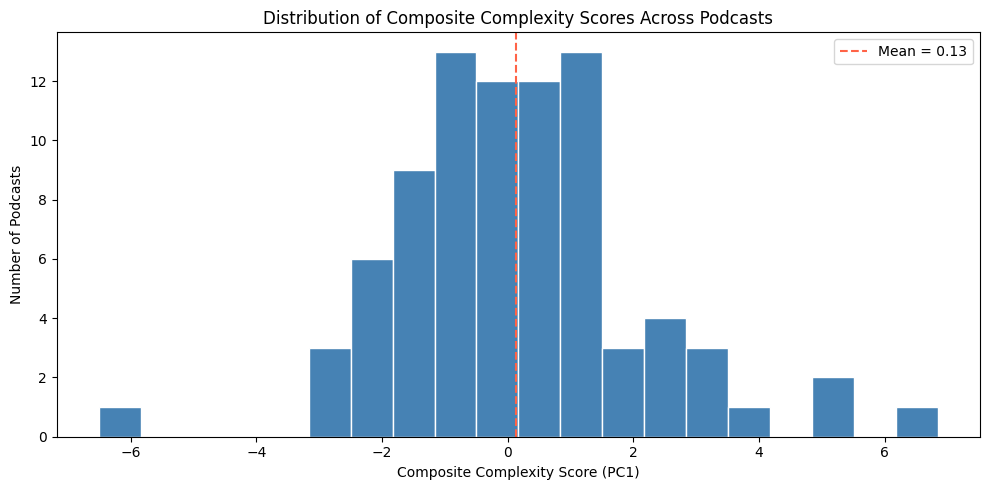

In [44]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = df_pod_means.dropna(subset=['complexity_score']).sort_values('complexity_score')

ax.hist(plot_df['complexity_score'], bins=20, color='steelblue', edgecolor='white')
ax.axvline(plot_df['complexity_score'].mean(), color='tomato', linestyle='--',
           label=f"Mean = {plot_df['complexity_score'].mean():.2f}")
ax.set_xlabel('Composite Complexity Score (PC1)')
ax.set_ylabel('Number of Podcasts')
ax.set_title('Distribution of Composite Complexity Scores Across Podcasts')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig_complexity_distribution.png', dpi=150)
plt.show()

### 7.4 Individual metric distributions across all episodes

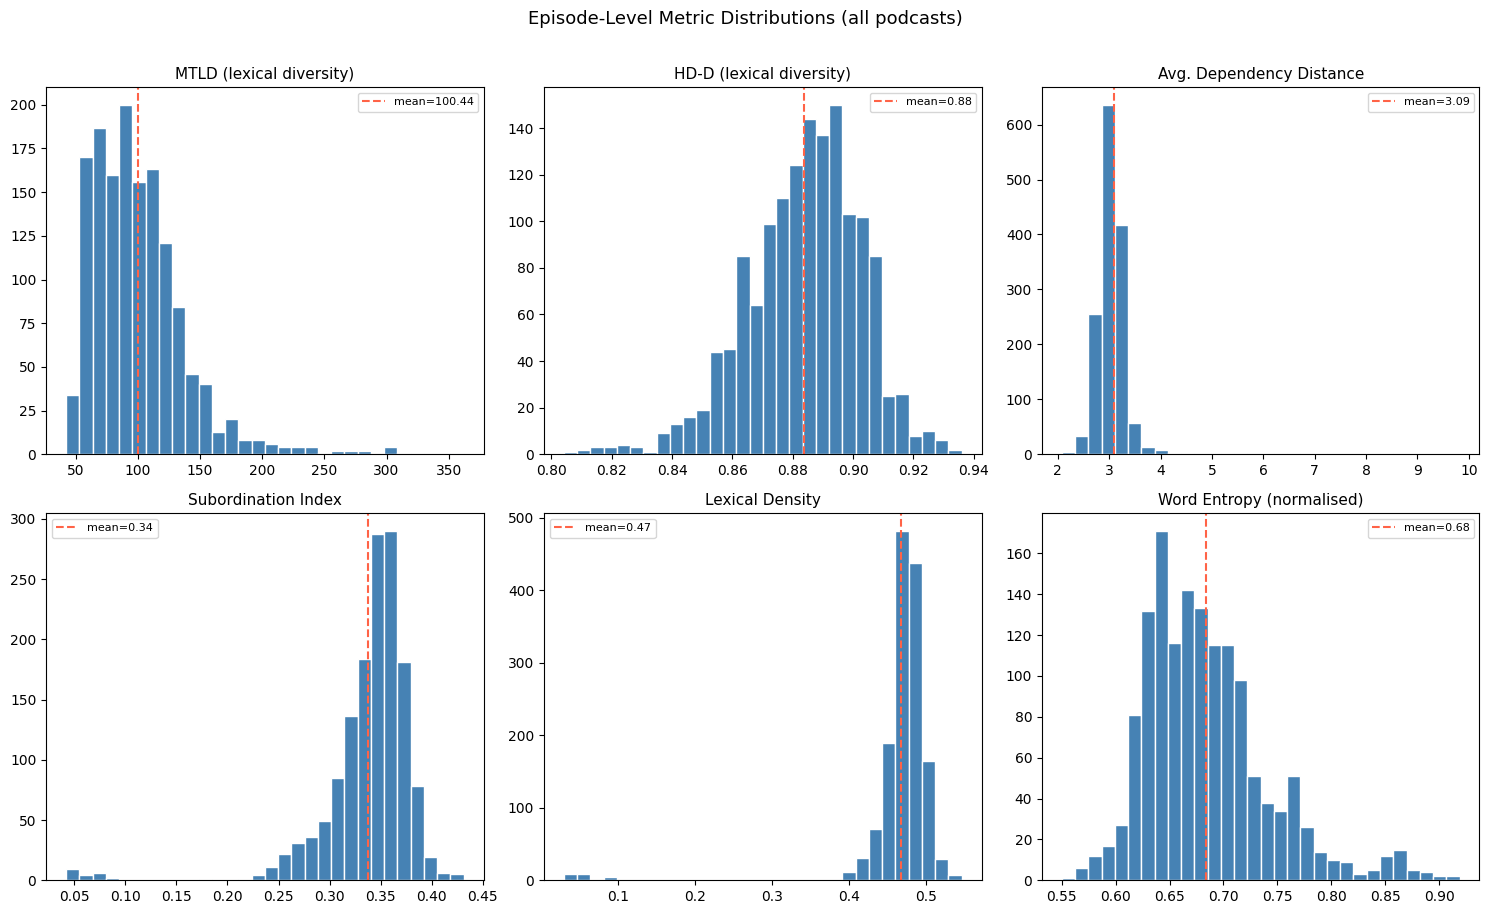

In [45]:
PLOT_METRICS = ['mtld', 'hdd', 'avg_dep_distance', 'subordination_idx',
                'lexical_density', 'word_entropy']
METRIC_LABELS = {
    'mtld': 'MTLD (lexical diversity)',
    'hdd': 'HD-D (lexical diversity)',
    'avg_dep_distance': 'Avg. Dependency Distance',
    'subordination_idx': 'Subordination Index',
    'lexical_density': 'Lexical Density',
    'word_entropy': 'Word Entropy (normalised)',
}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, metric in zip(axes, PLOT_METRICS):
    vals = df_metrics[metric].dropna()
    ax.hist(vals, bins=30, color='steelblue', edgecolor='white')
    ax.axvline(vals.mean(), color='tomato', linestyle='--', linewidth=1.5,
               label=f'mean={vals.mean():.2f}')
    ax.set_title(METRIC_LABELS.get(metric, metric), fontsize=11)
    ax.set_xlabel('')
    ax.legend(fontsize=8)

plt.suptitle('Episode-Level Metric Distributions (all podcasts)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig_metric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.5 Podcast ranking by complexity

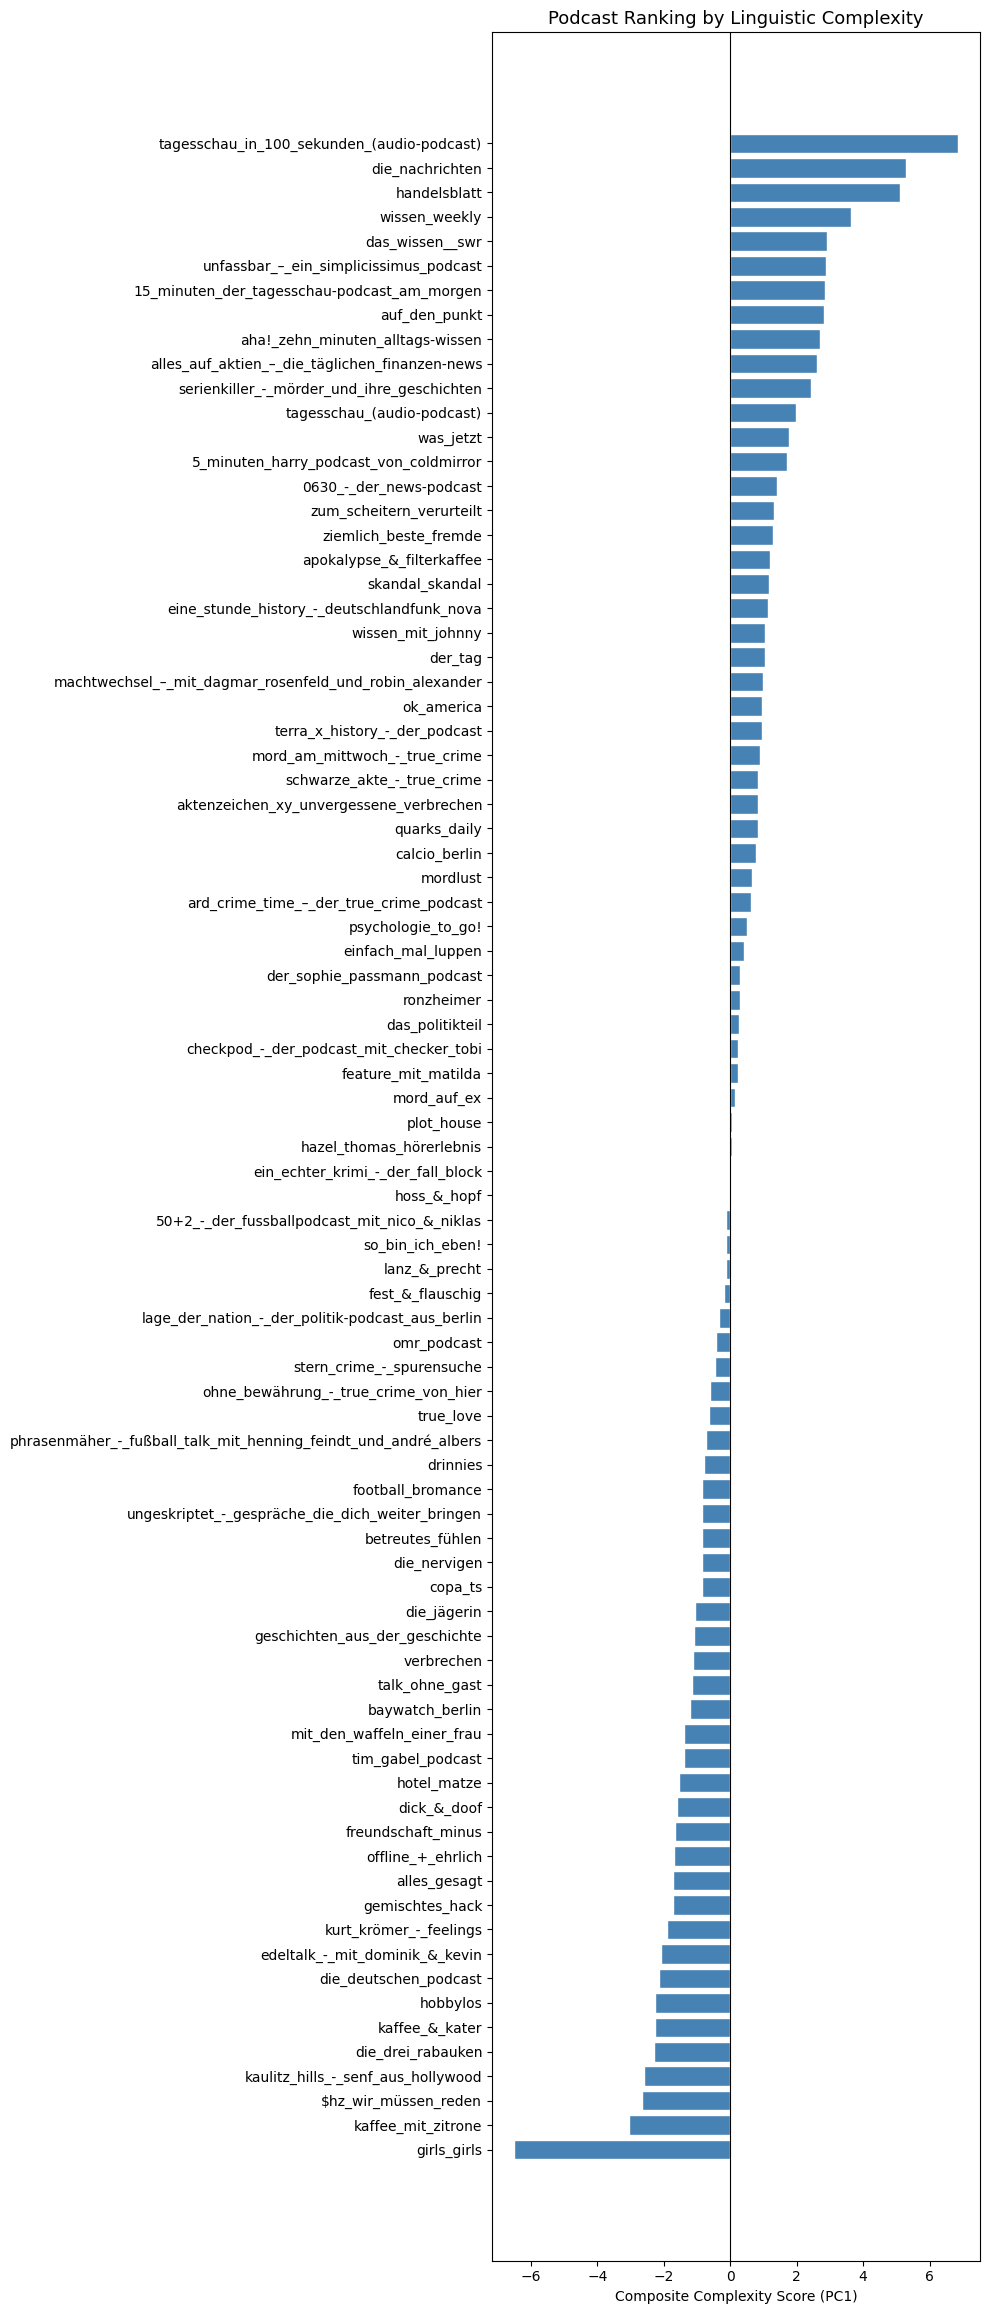

In [46]:
ranked = df_pod_means.dropna(subset=['complexity_score']).sort_values('complexity_score')

fig, ax = plt.subplots(figsize=(10, max(6, len(ranked) * 0.28)))

ax.barh(ranked['podcast'], ranked['complexity_score'], color='steelblue', edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Composite Complexity Score (PC1)')
ax.set_title('Podcast Ranking by Linguistic Complexity', fontsize=13)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig_podcast_ranking.png', dpi=150)
plt.show()

In [47]:
loadings['PC1']

ttr                 0.369
maas               -0.396
mtld                0.412
hdd                 0.371
word_entropy        0.350
pos_entropy         0.324
avg_dep_distance   -0.166
avg_sent_len        0.086
lexical_density     0.165
flesch_de_inv       0.333
Name: PC1, dtype: float64